In [1]:
# load data 
from ler.utils import get_param_from_json

data = get_param_from_json("broken_powerlaw_plus_2peaks_hyperparameters.json")
# data

In [2]:
# from ler.gw_source_population import CBCSourceParameterDistribution
# import numpy as np
# import matplotlib.pyplot as plt
# import contextlib
# from tqdm import tqdm

# m1_samples = []
# m2_samples = []
# m1_pdfs = []
# m1_arrs = []
# size = 5
# idx = np.random.choice(len(data["lam_0"]), size=size, replace=False)
# for i, j in tqdm(enumerate(idx), total=size, ncols=100):
#     # print(f"Sample {j+1}, idx {i}:")
#     # print(f"Hyperparameters: lam_0={data['lam_0'][i]}, lam_1={data['lam_1'][i]}, mpp_1={data['mpp_1'][i]}, sigpp_1={data['sigpp_1'][i]}, mpp_2={data['mpp_2'][i]}, sigpp_2={data['sigpp_2'][i]}, mlow_1={data['mlow_1'][i]}, delta_m_1={data['delta_m_1'][i]}, break_mass={data['break_mass'][i]}, alpha_1={data['alpha_1'][i]}, alpha_2={data['alpha_2'][i]}")
#     with contextlib.redirect_stdout(None):
#         cbc = CBCSourceParameterDistribution(
#             event_type="BBH",
#             gw_priors=dict(
#                 mass_1_source="broken_powerlaw_plus_2peaks"
#             ),
#             gw_priors_params=dict(
#                 mass_1_source=dict(
#                     param_name="mass_1_source",
#                     sampler_type="broken_powerlaw_plus_2peaks",
#                     lam_0=data["lam_0"][i],
#                     lam_1=data["lam_1"][i],
#                     mpp_1=data["mpp_1"][i],
#                     sigpp_1=data["sigpp_1"][i],
#                     mpp_2=data["mpp_2"][i],
#                     sigpp_2=data["sigpp_2"][i],
#                     mlow_1=data["mlow_1"][i],
#                     delta_m_1=data["delta_m_1"][i],
#                     break_mass=data["break_mass"][i],
#                     alpha_1=data["alpha_1"][i],
#                     alpha_2=data["alpha_2"][i],
#                     mmax=300.0,
#                     normalization_size=500,
#                 ),
#             ),
#             spin_zero=False,
#             spin_precession=True,
#         )

#         gw_param = cbc.sample_gw_parameters(size=10000)
#         m1_samples.append(gw_param["mass_1_source"])
#         m2_samples.append(gw_param["mass_2_source"])
#         m1_arr = np.geomspace(data["mlow_1"][i], 300, 200)
#         m1_pdfs.append(cbc.mass_1_source.pdf(m1_arr))
#         m1_arrs.append(m1_arr)

# m1_samples = np.array(m1_samples)
# m2_samples = np.array(m2_samples)
# m1_pdfs = np.array(m1_pdfs)
# m1_arrs = np.array(m1_arrs)
# # 10 samples: 26s
# # 100 samples: 3m43s

In [ ]:
from ler.gw_source_population import CBCSourceParameterDistribution
import numpy as np
import matplotlib.pyplot as plt
import contextlib
from tqdm import tqdm

m1_samples = []
m1_pdfs = []
m1_arrs = []
size = 100
idx = np.random.choice(len(data["lam_0"]), size=size, replace=False)

i = 0
cbc = CBCSourceParameterDistribution(
    event_type="BBH",
    gw_priors=dict(
        mass_1_source="broken_powerlaw_plus_2peaks"
    ),
    spin_zero=False,
    spin_precession=True,
)

m1_arr_median = np.geomspace(5.059, 300, 1000)
P_0 = cbc.mass_1_source.pdf(m1_arr_median)

for i, j in tqdm(enumerate(idx), total=size, ncols=100):
    # print(f"Sample {j+1}, idx {i}:")
    # print(f"Hyperparameters: lam_0={data['lam_0'][i]}, lam_1={data['lam_1'][i]}, mpp_1={data['mpp_1'][i]}, sigpp_1={data['sigpp_1'][i]}, mpp_2={data['mpp_2'][i]}, sigpp_2={data['sigpp_2'][i]}, mlow_1={data['mlow_1'][i]}, delta_m_1={data['delta_m_1'][i]}, break_mass={data['break_mass'][i]}, alpha_1={data['alpha_1'][i]}, alpha_2={data['alpha_2'][i]}")
    with contextlib.redirect_stdout(None):

        # reinit
        cbc.gw_param_samplers_params["mass_1_source"] = dict(
            param_name="mass_1_source",
            sampler_type="broken_powerlaw_plus_2peaks",
            lam_0=data["lam_0"][i],
            lam_1=data["lam_1"][i],
            mpp_1=data["mpp_1"][i],
            sigpp_1=data["sigpp_1"][i],
            mpp_2=data["mpp_2"][i],
            sigpp_2=data["sigpp_2"][i],
            mlow_1=data["mlow_1"][i],
            delta_m_1=data["delta_m_1"][i],
            break_mass=data["break_mass"][i],
            alpha_1=data["alpha_1"][i],
            alpha_2=data["alpha_2"][i],
            mmax=300.0,
            normalization_size=500,
        )
        # cbc.gw_param_samplers["mass_1_source"] = "broken_powerlaw_plus_2peaks"
        cbc.mass_1_source = cbc.gw_param_samplers["mass_1_source"]
        

        mass_1_source = cbc.mass_1_source.rvs(size=20000)
        m1_samples.append(mass_1_source)
        m1_arr = np.geomspace(data["mlow_1"][i], 300, 200)
        m1_pdfs.append(cbc.mass_1_source.pdf(m1_arr))
        m1_arrs.append(m1_arr)
        cbc.sample_gw_parameters_routine = cbc._initialization_gw_parameters_sampler()

m1_samples = np.array(m1_samples)
m1_pdfs = np.array(m1_pdfs)
m1_arrs = np.array(m1_arrs)
# 100 samples: 1m22s


Initializing CBCSourceRedshiftDistribution class...

luminosity_distance interpolator will be loaded from ./interpolator_json/luminosity_distance/luminosity_distance_0.json
differential_comoving_volume interpolator will be loaded from ./interpolator_json/differential_comoving_volume/differential_comoving_volume_0.json
using ler available merger rate density model: merger_rate_density_madau_dickinson_belczynski_ng
merger_rate_density_madau_dickinson_belczynski_ng interpolator will be loaded from ./interpolator_json/merger_rate_density/merger_rate_density_madau_dickinson_belczynski_ng_0.json
merger_rate_density_madau_dickinson_belczynski_ng_detector_frame interpolator will be loaded from ./interpolator_json/merger_rate_density/merger_rate_density_madau_dickinson_belczynski_ng_detector_frame_1.json
source_redshift interpolator will be loaded from ./interpolator_json/source_redshift/source_redshift_0.json

Initializing CBCSourceParameterDistribution class...

using ler available zs functi

100%|█████████████████████████████████████████████████████████████| 100/100 [00:20<00:00,  4.82it/s]


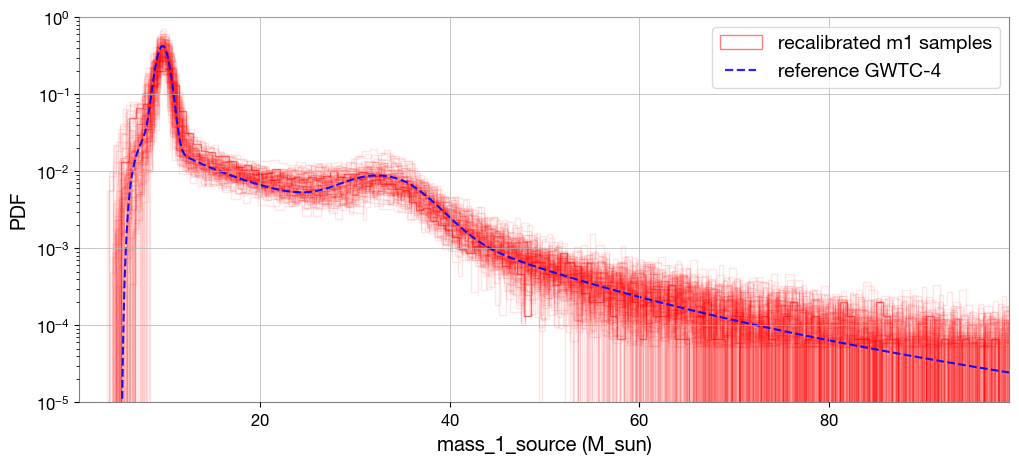

In [4]:
# Plotting the distribution of m1 and m2
import matplotlib.pyplot as plt

size = len(m1_samples)

plt.figure(figsize=(12, 5))
for i in range(size):
    plt.hist(m1_samples[i], bins=300, density=True, alpha=0.1, color='r', histtype='step')
    # plt.plot(m1_arrs[i], m1_pdfs[i], 'y-', alpha=0.1, linewidth=2)
plt.plot(m1_arr_median, P_0, 'b--', alpha=0.9, linewidth=1.5, label="median hyperparameters")

# keep plotted style, but expose only one histogram entry in legend
ax = plt.gca()
if ax.patches:
    for p in ax.patches:
        p.set_label("_nolegend_")
    ax.patches[0].set_label("recalibrated m1 samples")
    ax.patches[0].set_alpha(0.5)  # set alpha for histogram entries

    ax.lines[0].set_label("recalibrated m1 PDF")
    ax.lines[0].set_alpha(0.5)  # set alpha for line entries


if ax.lines:
    ax.lines[-1].set_label("reference GWTC-4")
    ax.lines[-1].set_alpha(0.9)  # set alpha for line entries

legend = plt.legend(
    handlelength=2.2,
    loc='upper right',
    bbox_to_anchor=(1, 1),
    frameon=True,
    fontsize=14,
    edgecolor='lightgray'
)
legend.get_frame().set_boxstyle('Round', pad=0.0, rounding_size=0.2)
for handle in legend.get_lines():
    handle.set_linewidth(1.6)
    handle.set_alpha(0.85)

plt.yscale('log')
plt.ylim(1e-5, 1.0)
# plt.xscale('log')
plt.xlim(1, 99)
plt.xlabel("mass_1_source (M_sun)")
plt.ylabel("PDF")
plt.show()

## Importance Sampling 

- original: P(m1|param0)
- target: P(m1|param1)

- sampling distribution: P(m1|param0) (original distribution)
- weight: w = P(m1|param1) / P(m1|param0) (likelihood ratio)

In [5]:
from ler.gw_source_population import CBCSourceParameterDistribution
from ler.gw_source_population.broken_powerlaw_plus_2peaks import broken_powerlaw_plus_2peaks_pdf

import numpy as np
import matplotlib.pyplot as plt
import contextlib
from tqdm import tqdm

m1_samples = []
size = 100
idx = np.random.choice(len(data["lam_0"]), size=size, replace=False)

# median 
# original: P(m1|param0)
cbc = CBCSourceParameterDistribution(
    event_type="BBH",
    gw_priors=dict(
        mass_1_source="broken_powerlaw_plus_2peaks"
    ),
    spin_zero=False,
    spin_precession=True,
)
m1_samples_median = cbc.mass_1_source.rvs(size=200000) 
P_0 = broken_powerlaw_plus_2peaks_pdf(
    m1_samples_median,
    lam_0=0.361,
    lam_1=0.586,
    mpp_1=9.764,
    sigpp_1=0.649,
    mpp_2=32.763,
    sigpp_2=3.918,
    mlow_1=5.059,
    delta_m_1=4.321,
    break_mass=35.622,
    alpha_1=1.728,
    alpha_2=4.512,
    mmax=300.0,
    normalization_size=500,
)
m1_arr = np.geomspace(5.059, 300, 200)
pdf_ = broken_powerlaw_plus_2peaks_pdf(
    m1_arr,
    lam_0=0.361,
    lam_1=0.586,
    mpp_1=9.764,
    sigpp_1=0.649,
    mpp_2=32.763,
    sigpp_2=3.918,
    mlow_1=5.059,
    delta_m_1=4.321,
    break_mass=35.622,
    alpha_1=1.728,
    alpha_2=4.512,
    mmax=300.0,
    normalization_size=500,
)

for i, j in tqdm(enumerate(idx), total=size, ncols=100):
    P_i = broken_powerlaw_plus_2peaks_pdf(
        m1_samples_median,
        lam_0=data["lam_0"][i],
        lam_1=data["lam_1"][i],
        mpp_1=data["mpp_1"][i],
        sigpp_1=data["sigpp_1"][i],
        mpp_2=data["mpp_2"][i],
        sigpp_2=data["sigpp_2"][i],
        mlow_1=data["mlow_1"][i],
        delta_m_1=data["delta_m_1"][i],
        break_mass=data["break_mass"][i],
        alpha_1=data["alpha_1"][i],
        alpha_2=data["alpha_2"][i],
        mmax=300.0,
        normalization_size=500,
    )

    w_i = P_i / P_0
    # select only 10% of samples from m1_samples_median without replacement, with probabilities w_i
    selected_samples = np.random.choice(m1_samples_median, size=int(0.1 * len(m1_samples_median)), replace=False, p=w_i/np.sum(w_i))
    m1_samples.append(selected_samples)

m1_samples = np.array(m1_samples)


Initializing CBCSourceRedshiftDistribution class...

luminosity_distance interpolator will be loaded from ./interpolator_json/luminosity_distance/luminosity_distance_0.json
differential_comoving_volume interpolator will be loaded from ./interpolator_json/differential_comoving_volume/differential_comoving_volume_0.json
using ler available merger rate density model: merger_rate_density_madau_dickinson_belczynski_ng
merger_rate_density_madau_dickinson_belczynski_ng interpolator will be loaded from ./interpolator_json/merger_rate_density/merger_rate_density_madau_dickinson_belczynski_ng_0.json
merger_rate_density_madau_dickinson_belczynski_ng_detector_frame interpolator will be loaded from ./interpolator_json/merger_rate_density/merger_rate_density_madau_dickinson_belczynski_ng_detector_frame_1.json
source_redshift interpolator will be loaded from ./interpolator_json/source_redshift/source_redshift_0.json

Initializing CBCSourceParameterDistribution class...

using ler available zs functi

100%|█████████████████████████████████████████████████████████████| 100/100 [00:01<00:00, 64.41it/s]


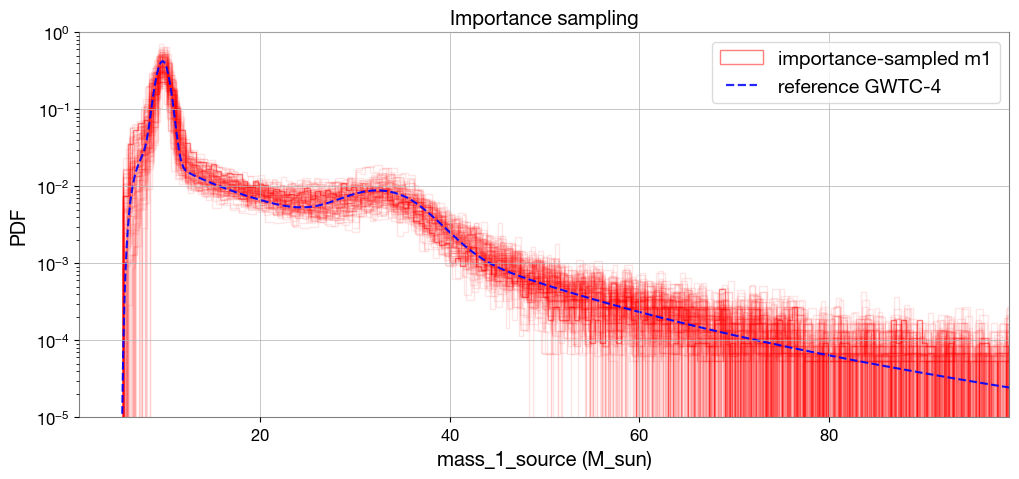

In [6]:
# Plotting the distribution of m1 and m2
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
for i in range(size):
    plt.hist(m1_samples[i], bins=300, density=True, alpha=0.1, color='r', histtype='step')
plt.plot(m1_arr, pdf_, 'b--', alpha=0.9, linewidth=1.5)

# Add legend
# ---------- Legend ----------
ax = plt.gca()

# keep plotted style, but expose only one histogram entry in legend
if ax.patches:
    for p in ax.patches:
        p.set_label("_nolegend_")
    ax.patches[0].set_label("importance-sampled m1")
    ax.patches[0].set_alpha(0.5)  # set alpha for histogram entries


if ax.lines:
    ax.lines[-1].set_label("reference GWTC-4")
    ax.lines[-1].set_alpha(0.9)  # set alpha for line entries

legend = plt.legend(
    handlelength=2.2,
    loc='upper right',
    bbox_to_anchor=(1, 1),
    frameon=True,
    fontsize=14,
    edgecolor='lightgray'
)
legend.get_frame().set_boxstyle('Round', pad=0.0, rounding_size=0.2)
for handle in legend.get_lines():
    handle.set_linewidth(1.6)
    handle.set_alpha(0.85)

plt.yscale('log')
plt.ylim(1e-5, 1.0)
# plt.xscale('log')
plt.xlim(1, 99)
plt.title("Importance sampling")
plt.xlabel("mass_1_source (M_sun)")
plt.ylabel("PDF")
plt.show()